In [1]:
import os
import glob
from pathlib import Path
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from torch.utils.data import Dataset
from PIL import Image
import os

class BreaKHisDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


In [3]:
import os
import glob
from pathlib import Path

def get_image_paths_and_labels(root_dir):
    file_paths = []
    labels = []
    
    
    class_mapping = {
        'SOB_B_A': 0,   
        'SOB_B_F': 1,   
        'SOB_B_PT': 2,   
        'SOB_B_TA': 3,   
        'SOB_M_DC': 4,   
        'SOB_M_LC': 5,   
        'SOB_M_MC': 6,   
        'SOB_M_PC': 7    
    }
    
    
    img_extensions = ('.png', '.jpg', '.jpeg')
    
   
    for class_dir in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_dir)
        
        if not os.path.isdir(class_path):
            continue
            
       
        if class_dir in class_mapping:
            label = class_mapping[class_dir]
        else:
            print(f"Skipping unknown directory: {class_dir}")
            continue
            
       
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(img_extensions):
                file_paths.append(os.path.join(class_path, img_file))
                labels.append(label)
    
    print(f"Found {len(file_paths)} images across {len(class_mapping)} classes.")
    print("Class distribution:", np.bincount(labels))
    return file_paths, labels, list(class_mapping.keys())

In [4]:
IMG_SIZE = 227
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])


In [5]:
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


train_dir = "/kaggle/input/final1/balanced_dataset"
train_paths, train_labels, class_names = get_image_paths_and_labels(train_dir)
train_dataset = BreaKHisDataset(train_paths, train_labels, train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dir = "/kaggle/input/split-data/BreakHis_splits/val/"
val_paths, val_labels, _ = get_image_paths_and_labels(val_dir)
val_dataset = BreaKHisDataset(val_paths, val_labels, test_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dir = "/kaggle/input/split-data/BreakHis_splits/test/"
test_paths, test_labels, _ = get_image_paths_and_labels(test_dir)
test_dataset = BreaKHisDataset(test_paths, test_labels, test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Found 8000 images across 8 classes.
Class distribution: [1000 1000 1000 1000 1000 1000 1000 1000]
Found 400 images across 8 classes.
Class distribution: [50 50 50 50 50 50 50 50]
Found 800 images across 8 classes.
Class distribution: [100 100 100 100 100 100 100 100]


In [6]:
import torch
import torch.nn as nn
from torchvision import models

class EfficientNetB3(nn.Module):
    def __init__(self, num_classes=8):
        super(EfficientNetB3, self).__init__()
        self.backbone = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EfficientNetB3().to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 192MB/s]


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

best_val_acc = 0.0
num_epochs = 50
patience = 10
early_stop_counter = 0


In [8]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_mobilenet.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/50 | Loss: 1.7012 | Val Acc: 0.5925
Epoch 2/50 | Loss: 1.1706 | Val Acc: 0.7825
Epoch 3/50 | Loss: 0.9695 | Val Acc: 0.8075
Epoch 4/50 | Loss: 0.8763 | Val Acc: 0.8975
Epoch 5/50 | Loss: 0.8118 | Val Acc: 0.9050
Epoch 6/50 | Loss: 0.7614 | Val Acc: 0.9100
Epoch 7/50 | Loss: 0.7396 | Val Acc: 0.9075
Epoch 8/50 | Loss: 0.6949 | Val Acc: 0.9450
Epoch 9/50 | Loss: 0.6781 | Val Acc: 0.9425
Epoch 10/50 | Loss: 0.6691 | Val Acc: 0.9325
Epoch 11/50 | Loss: 0.6507 | Val Acc: 0.9200
Epoch 12/50 | Loss: 0.6250 | Val Acc: 0.9150
Epoch 13/50 | Loss: 0.6290 | Val Acc: 0.9275
Epoch 14/50 | Loss: 0.6154 | Val Acc: 0.9175
Epoch 15/50 | Loss: 0.6145 | Val Acc: 0.9250
Epoch 16/50 | Loss: 0.6013 | Val Acc: 0.9325
Epoch 17/50 | Loss: 0.6013 | Val Acc: 0.9450
Epoch 18/50 | Loss: 0.5906 | Val Acc: 0.9300
Early stopping triggered.


In [9]:
model.load_state_dict(torch.load("best_mobilenet.pth"))
model.eval()


<ipython-input-9-d1e8026d5c3d>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mobilenet.pth"))


EfficientNetB3(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (s


Overall Test Accuracy: 0.9313
Benign Accuracy: 0.9375 | Malignant Accuracy: 0.9250

Per-Class Accuracy:
  adenosis: 0.9700
  fibroadenoma: 0.9000
  phyllodes_tumor: 0.8900
  tubular_adenoma: 0.9900
  ductal_carcinoma: 0.8200
  lobular_carcinoma: 0.9600
  mucinous_carcinoma: 0.9600
  papillary_carcinoma: 0.9600


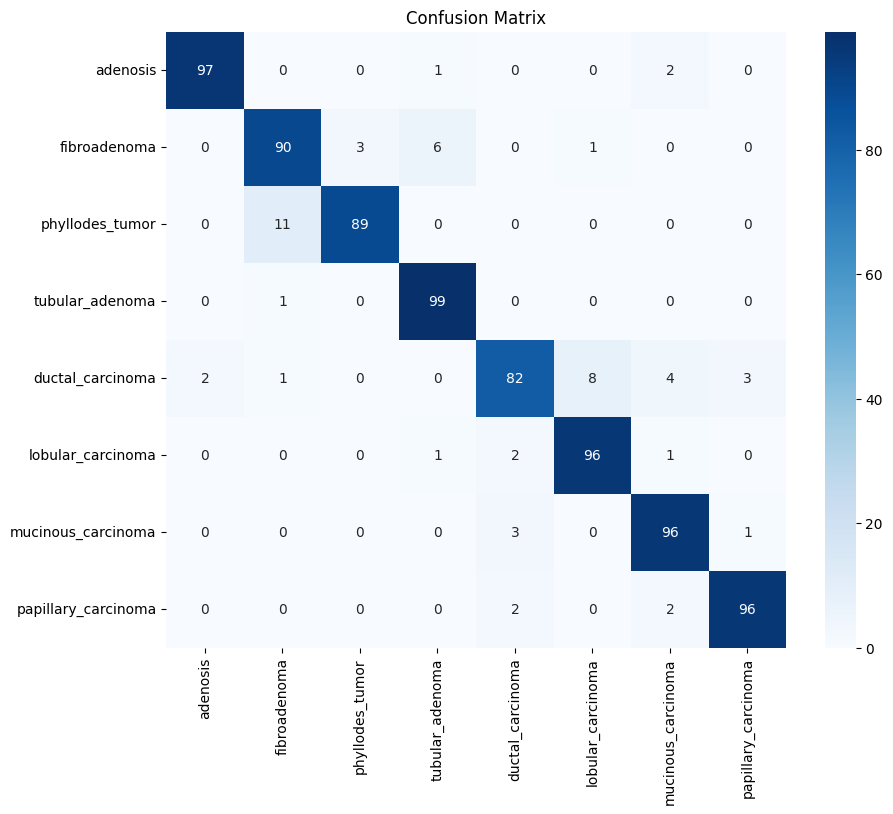


Classification Report:
                     precision    recall  f1-score   support

           adenosis     0.9798    0.9700    0.9749       100
       fibroadenoma     0.8738    0.9000    0.8867       100
    phyllodes_tumor     0.9674    0.8900    0.9271       100
    tubular_adenoma     0.9252    0.9900    0.9565       100
   ductal_carcinoma     0.9213    0.8200    0.8677       100
  lobular_carcinoma     0.9143    0.9600    0.9366       100
 mucinous_carcinoma     0.9143    0.9600    0.9366       100
papillary_carcinoma     0.9600    0.9600    0.9600       100

           accuracy                         0.9313       800
          macro avg     0.9320    0.9312    0.9308       800
       weighted avg     0.9320    0.9313    0.9308       800



In [10]:

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


class_names = [
    'adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma',
    'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma'
]


overall_acc = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Accuracy: {overall_acc:.4f}")

benign_classes = [0, 1, 2, 3]
malignant_classes = [4, 5, 6, 7]
benign_acc = accuracy_score(
    np.array(all_labels)[np.isin(all_labels, benign_classes)],
    np.array(all_preds)[np.isin(all_labels, benign_classes)]
)
malignant_acc = accuracy_score(
    np.array(all_labels)[np.isin(all_labels, malignant_classes)],
    np.array(all_preds)[np.isin(all_labels, malignant_classes)]
)
print(f"Benign Accuracy: {benign_acc:.4f} | Malignant Accuracy: {malignant_acc:.4f}")

print("\nPer-Class Accuracy:")
for i, name in enumerate(class_names):
    class_idx = np.array(all_labels) == i
    acc = accuracy_score(np.array(all_labels)[class_idx], np.array(all_preds)[class_idx])
    print(f"  {name}: {acc:.4f}")


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cm, index=class_names, columns=class_names), 
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))